In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from metrics import *

In [2]:
buyAndHold = pd.read_csv("C:/Users/Miles/Documents/ml_project_cv/Predictions/BuyAndHoldStrategy.csv", index_col='Date', parse_dates=True)
momentumStrategy = pd.read_csv("C:/Users/Miles/Documents/ml_project_cv/Predictions/MomentumStrategy.csv", index_col='Date', parse_dates=True)
decisionTree = pd.read_csv("C:/Users/Miles/Documents/ml_project_cv/Predictions/DecisionTree.csv", index_col='Date', parse_dates=True)
randomForest = pd.read_csv("C:/Users/Miles/Documents/ml_project_cv/Predictions/RandomForest.csv", index_col='Date', parse_dates=True)
neuralNetwork = pd.read_csv("C:/Users/Miles/Documents/ml_project_cv/Predictions/NeuralNetwork.csv", index_col='Date', parse_dates=True)

In [3]:
allPrices = yf.download(tickers = "SPY", interval="1d", start="2015-01-01", auto_adjust=True)
allPrices

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2015-01-02,169.687820,170.885549,168.655304,170.472543,121465900
2015-01-05,166.623322,168.812251,166.317701,168.647051,169632600
2015-01-06,165.053955,167.449388,164.260977,166.928996,209151400
2015-01-07,167.110687,167.449356,165.929495,166.375536,125346700
2015-01-08,170.076096,170.290867,168.498420,168.514931,147217800
...,...,...,...,...,...
2026-08-24,763.469971,765.219971,762.080017,764.780029,32430900
2026-08-25,765.909973,766.780029,763.049988,766.159973,27422300


In [4]:
returns = allPrices["Close"].pct_change().dropna()
returns

Ticker,SPY
Date,
2015-01-05,-0.018060
2015-01-06,-0.009419
2015-01-07,0.012461
2015-01-08,0.017745
2015-01-09,-0.008014
...,...
2026-08-24,-0.002938
2026-08-25,0.003196
2026-08-26,0.000222


In [5]:
def ApplyStrategy(returns, strategy):

    returns = returns.reindex(buyAndHold.index)
    
    strategyReturns = returns.copy()
    strategyReturns["Strategy Return"] = (
        returns.iloc[:, 0] * strategy["Prediction"]
    )
    
    return strategyReturns[["Strategy Return"]]


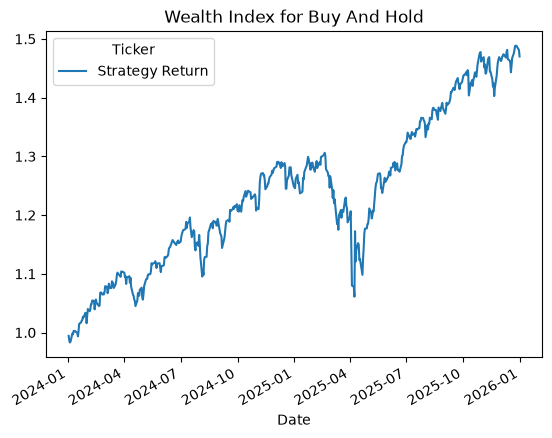

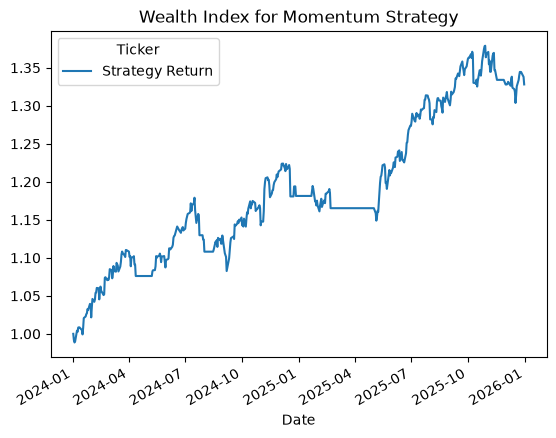

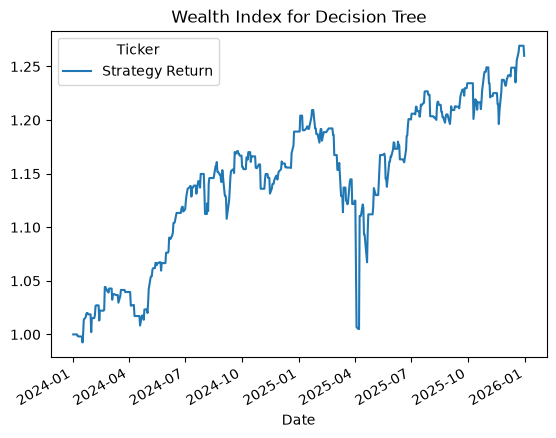

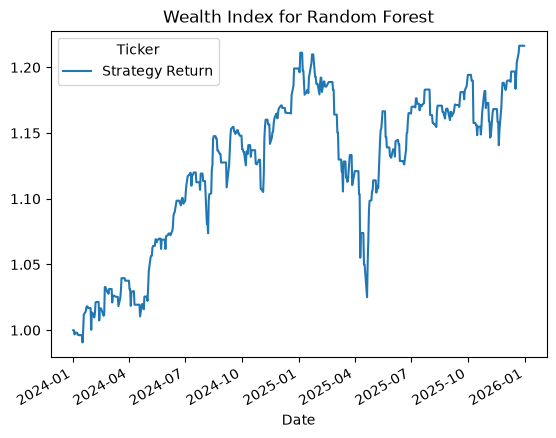

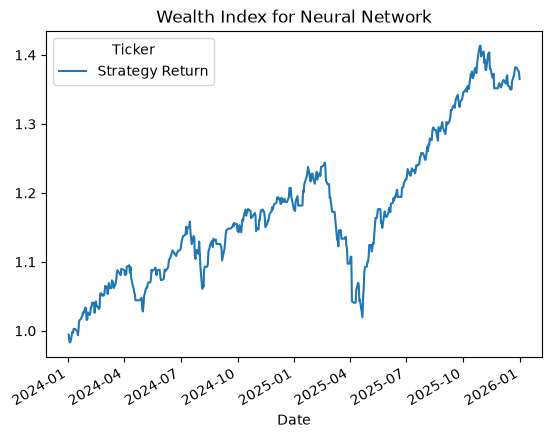

In [6]:
buyAndHoldReturns = ApplyStrategy(returns, buyAndHold)
momentumStrategyReturns = ApplyStrategy(returns, momentumStrategy)
decisionTreeReturns = ApplyStrategy(returns, decisionTree)
randomForestReturns = ApplyStrategy(returns, randomForest)
neuralNetworkReturns = ApplyStrategy(returns, neuralNetwork)

data = {
    "Total Return": [totalReturn(buyAndHoldReturns),totalReturn(momentumStrategyReturns),totalReturn(decisionTreeReturns),totalReturn(randomForestReturns),totalReturn(neuralNetworkReturns)],
    "Annualised Return": [annualisedReturn(buyAndHoldReturns),annualisedReturn(momentumStrategyReturns),annualisedReturn(decisionTreeReturns),annualisedReturn(randomForestReturns),annualisedReturn(neuralNetworkReturns)],
    "Annualised Volatility": [annualisedVolatility(buyAndHoldReturns), annualisedVolatility(momentumStrategyReturns), annualisedVolatility(decisionTreeReturns),annualisedVolatility(randomForestReturns), annualisedVolatility(neuralNetworkReturns)],
    "Sharpe Ratio": [rawSharpsRatio(buyAndHoldReturns),rawSharpsRatio(momentumStrategyReturns),rawSharpsRatio(decisionTreeReturns),rawSharpsRatio(randomForestReturns),rawSharpsRatio(neuralNetworkReturns)],
    "Max Drawdown": [maxiumumDrawDown(buyAndHoldReturns, "Buy And Hold"),maxiumumDrawDown(momentumStrategyReturns, "Momentum Strategy"),maxiumumDrawDown(decisionTreeReturns, "Decision Tree"),maxiumumDrawDown(randomForestReturns, "Random Forest"),maxiumumDrawDown(neuralNetworkReturns, "Neural Network")]
}


In [7]:
results = pd.DataFrame(data, index = ["Buy and Hold", "Momentum Strategy", "Decision Tree", "Random Forest", "Neural Network"])
results

,Total Return,Annualised Return,Annualised Volatility,Sharpe Ratio,Max Drawdown
Buy and Hold,0.470152,0.213429,0.163676,1.303972,-0.187552
Momentum Strategy,0.328079,0.153074,0.100478,1.523458,-0.081785
Decision Tree,0.259939,0.122987,0.136430,0.901463,-0.168997
Random Forest,0.216412,0.103341,0.108803,0.949805,-0.153623
Neural Network,0.365016,0.169064,0.123796,1.365661,-0.180457


The Buy and Hold strategy gave the best total return and best annualised return. However, all the other strategies had a smaller maximum drawdown and lower volatility, indicating less overall risk. The Neural Network and the Momentum strategy both achieved a greater Sharpe ratio, meaning they offered a better risk-adjusted return than Buy and Hold. However, the Decision Tree and Random Forest greatly underperformed. This could have been due to poor implementation, the limited feature set, or the algorithm simply not suit to predicting stock price direction.